2. 해당 소스를 이용하여 ML 분류 RF, LR, DT

3. 해당 소스를 이용하여 FCNN

4. 해당 소스를 이용하여 CNN

5. 모든 소스에는 F1값 및 confusion matrix 표시

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats  # 과학용 계산 라이브러리
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

In [90]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv(url, names=columns)

In [91]:
df

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good


In [92]:
df.columns

Index(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class'], dtype='object')

Text(0.5, 1.0, 'Label')

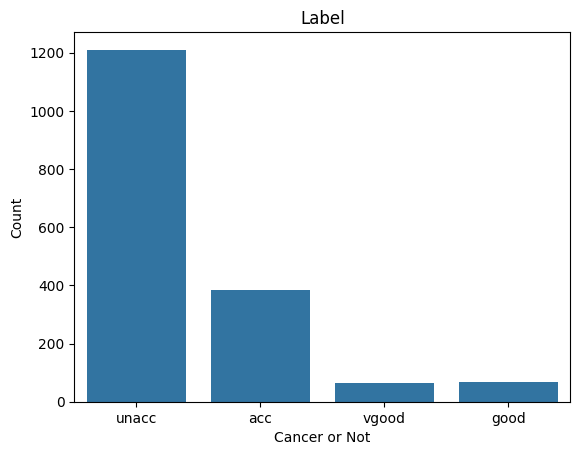

In [93]:
# 레이블 갯수 확인 (그래프)
sns.countplot(data = df, x="class")
plt.xlabel("Cancer or Not")
plt.ylabel("Count")
plt.title("Label")

In [94]:
df['class'].value_counts()

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [95]:
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [96]:
# 결측치 제거
df = df.dropna()
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [97]:
df_label=df

In [98]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df_label['buying'] = label_encoder.fit_transform(df_label['buying'])
df_label['maint'] = label_encoder.fit_transform(df_label['maint'])
df_label['lug_boot'] = label_encoder.fit_transform(df_label['lug_boot'])
df_label['safety'] = label_encoder.fit_transform(df_label['safety'])
df_label['doors'] = label_encoder.fit_transform(df_label['doors'])
df_label['persons'] = label_encoder.fit_transform(df_label['persons'])
df_label['class'] = label_encoder.fit_transform(df_label['class'])
df_label.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [99]:
X=df_label.drop('class',axis=1)
X.head()

,buying,maint,doors,persons,lug_boot,safety
0,3,3,0,0,2,1
1,3,3,0,0,2,2
2,3,3,0,0,2,0
3,3,3,0,0,1,1
4,3,3,0,0,1,2


In [100]:
y=df_label['class']
y.value_counts()

class
2    1210
0     384
1      69
3      65
Name: count, dtype: int64

In [101]:
Y = pd.get_dummies(y).values

In [102]:
X= X.values

In [103]:
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42) 

In [107]:
X_train.shape,X_test.shape, y_train.shape,y_test.shape

((1382, 6), (346, 6), (1382, 4), (346, 4))

In [116]:
#Defining the model 

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam

model = Sequential()

model.add(Dense(10,input_shape=(6,),activation='tanh'))
model.add(Dense(300,activation='tanh'))
model.add(Dense(300,activation='tanh'))
model.add(Dense(4,activation='softmax'))

model.compile(Adam(lr=0.04),'categorical_crossentropy',metrics=['accuracy'])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_28 (Dense)            (None, 10)                70        
                                                                 
 dense_29 (Dense)            (None, 300)               3300      
                                                                 
 dense_30 (Dense)            (None, 300)               90300     
                                                                 
 dense_31 (Dense)            (None, 4)                 1204      
                                                                 
Total params: 94874 (370.60 KB)
Trainable params: 94874 (370.60 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [117]:
model_history=model.fit(x=X_train, y=y_train, epochs=30, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test,axis=1)
y_pred_class = np.argmax(y_pred,axis=1)

Epoch 1/30
44/44 [==============================] - 2s 11ms/step - loss: 0.8226 - accuracy: 0.6860 - val_loss: 0.7771 - val_accuracy: 0.6590
Epoch 2/30
44/44 [==============================] - 0s 6ms/step - loss: 0.7175 - accuracy: 0.7041 - val_loss: 0.7885 - val_accuracy: 0.6503
Epoch 3/30
44/44 [==============================] - 0s 6ms/step - loss: 0.7311 - accuracy: 0.7019 - val_loss: 0.7607 - val_accuracy: 0.6705
Epoch 4/30
44/44 [==============================] - 0s 5ms/step - loss: 0.7147 - accuracy: 0.7055 - val_loss: 0.7401 - val_accuracy: 0.6503
Epoch 5/30
44/44 [==============================] - 0s 5ms/step - loss: 0.7067 - accuracy: 0.7142 - val_loss: 0.6981 - val_accuracy: 0.6734
Epoch 6/30
44/44 [==============================] - 0s 6ms/step - loss: 0.6802 - accuracy: 0.7077 - val_loss: 0.7042 - val_accuracy: 0.6763
Epoch 7/30
44/44 [==============================] - 0s 5ms/step - loss: 0.6750 - accuracy: 0.7098 - val_loss: 0.6919 - val_accuracy: 0.6676
Epoch 8/30
44/44 [=

In [118]:
#Accuracy of the predicted values
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       0.71      0.78      0.75        83
           1       0.42      0.45      0.43        11
           2       0.95      0.97      0.96       235
           3       1.00      0.12      0.21        17

    accuracy                           0.87       346
   macro avg       0.77      0.58      0.59       346
weighted avg       0.88      0.87      0.86       346

[[ 65   6  12   0]
 [  6   5   0   0]
 [  5   1 229   0]
 [ 15   0   0   2]]
